In [22]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

from camscan import utils


def show_cv_image(img):
    # Check if the image is a black-and-whie image (only 2 dimensions)
    # In this case, it is only a binary 0 for black and 1 for white
    if len(img.shape) == 2:
        pass
    # Check if the image has 3 color dimensions (BGR).
    # If it does, we need to convert from OpenCV BGR to RGB before showing.
    elif img.shape[2] == 3:
        img = cv2.cvtColor(img,  cv2.COLOR_BGR2RGB)
    # Check if the image has 4 color dimensions (BGRA).
    # If it does, we need to convert from OpenCV BGRA to RGBA before showing.
    elif img.shape[2] == 4:
        img = cv2.cvtColor(img,  cv2.COLOR_BGRA2RGBA)
    else:
        raise ValueError(f"Unknown image shape: {img.shape}")
    plt.imshow(img)
    plt.show()

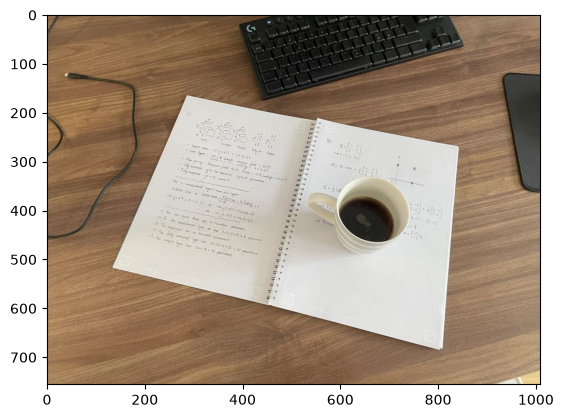

In [23]:
img_file = "../../tests/images/IMG_1846.jpg"
img = cv2.imread(img_file)
show_cv_image(img)

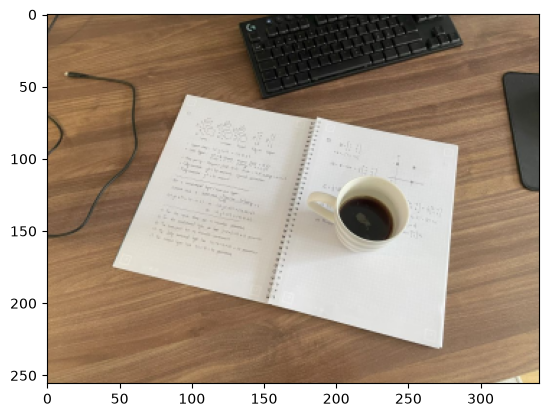

In [25]:
img_scale = utils.resize_with_aspect_ratio(
    image=img,
    height=256,
)
original_scale = img.shape[0] / img_scale.shape[0]
show_cv_image(img_scale)

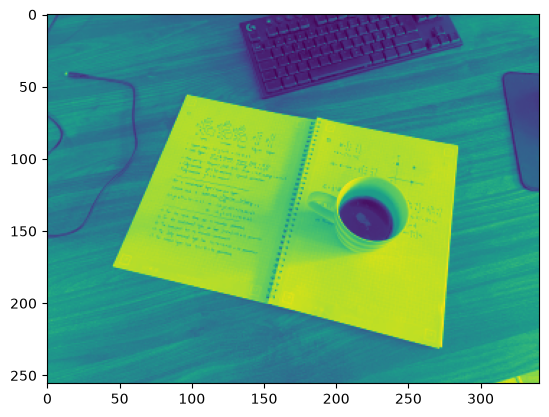

In [26]:
img_scale_gray = cv2.cvtColor(
    src=img_scale,
    code=cv2.COLOR_BGR2GRAY,
)
show_cv_image(img_scale_gray)

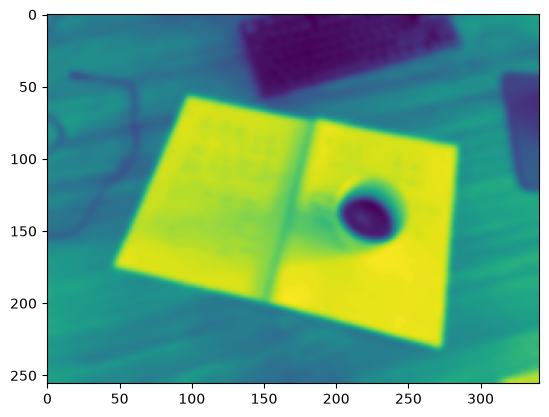

In [27]:
img_scale_gray_blur = cv2.GaussianBlur(
    src=img_scale_gray,
    ksize=(13, 13),
    sigmaX=0,
)
show_cv_image(img_scale_gray_blur)

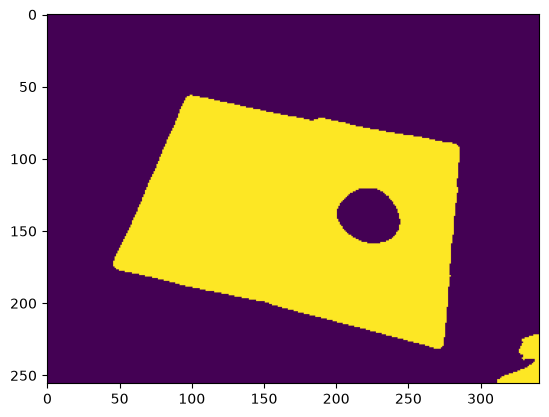

In [32]:
# do otsu threshold on gray image
thresh = cv2.threshold(
    img_scale_gray_blur,
    0,
    255,
    cv2.THRESH_BINARY+cv2.THRESH_OTSU
)[1]

show_cv_image(thresh)

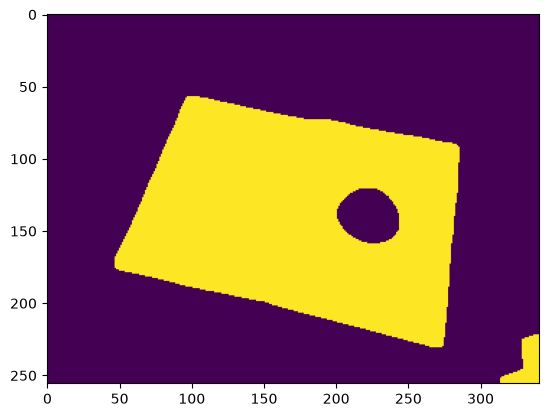

In [39]:
# apply morphology
kernel = np.ones((7,7), np.uint8)
morph = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
morph = cv2.morphologyEx(morph, cv2.MORPH_OPEN, kernel)

show_cv_image(morph)

2


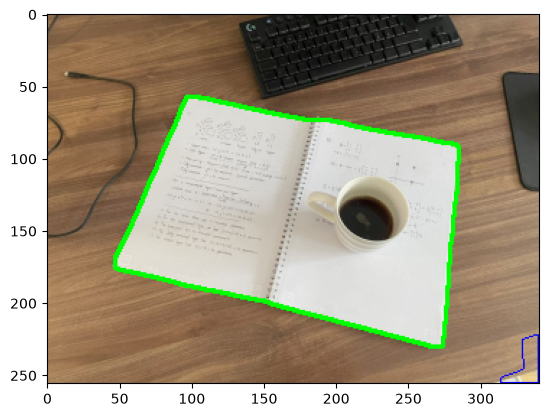

In [51]:
# get largest contour
contours = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(len(contours))
contours = contours[0] if len(contours) == 2 else contours[1]
area_thresh = 0

largest_contour_idx = 0

for i, c in enumerate(contours):
    area = cv2.contourArea(c)
    if area > area_thresh:
        area_thresh = area
        big_contour = c
        largest_contour_idx = i

page = img_scale.copy()

for i, contour in enumerate(contours):
    if i == largest_contour_idx:
        cv2.drawContours(page, [contour], 0, (0,255,0), 2)
    else:
        cv2.drawContours(page, [contour], 0, (255,0,0), 1)

show_cv_image(page)


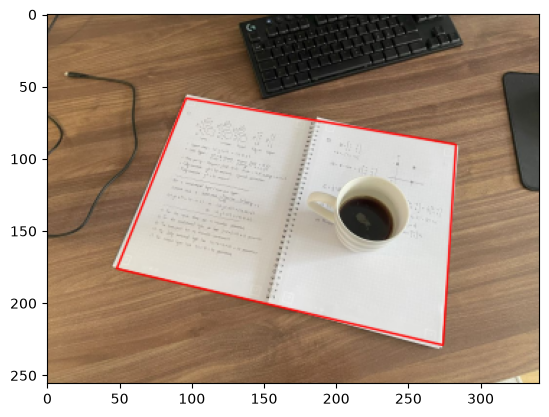

In [ ]:
# get perimeter and approximate a polygon
peri = cv2.arcLength(big_contour, True)
corners = cv2.approxPolyDP(big_contour, 0.04 * peri, True)

# draw polygon on input image from detected corners
polygon = img_scale.copy()
cv2.polylines(polygon, [corners], True, (0,0,255), 1, cv2.LINE_AA)
# Alternate: cv2.drawContours(page,[corners],0,(0,0,255),1)

show_cv_image(polygon)

In [15]:
big_contour

array([[[287, 165]],

       [[285, 167]],

       [[285, 168]],

       ...,

       [[295, 166]],

       [[292, 166]],

       [[291, 165]]], shape=(917, 1, 2), dtype=int32)